
[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
V4 - LIBRARIES
Libraries loaded successfully!

V4 - DATASET
Dataset loaded successfully!
Rows    : 20000
Columns : 16
Shape   : (20000, 16)

COLUMNS
- city
- state
- hour
- day_of_week
- is_weekend
- road_type
- lanes
- traffic_signal
- weather
- visibility
- temperature
- traffic_density
- cause
- vehicles_involved
- is_peak_hour
- accident_severity

MISSING VALUES
city                 0
state                0
hour                 0
day_of_week          0
is_weekend           0
road_type            0
lanes                0
traffic_signal       0
weather              0
visibility           0
temperature          0
traffic_density      0
cause                0
vehicles_involved    0
is_peak_hour         0
accident_severity    0
dtype: int64

TARGET DISTRIBUTION
accident_severity
major    9000
minor    8000
fatal    3000
Name: count, dtype: int64

Percentage:
accident_severity
major    45.0
minor    40.0
fatal    15.0
Name

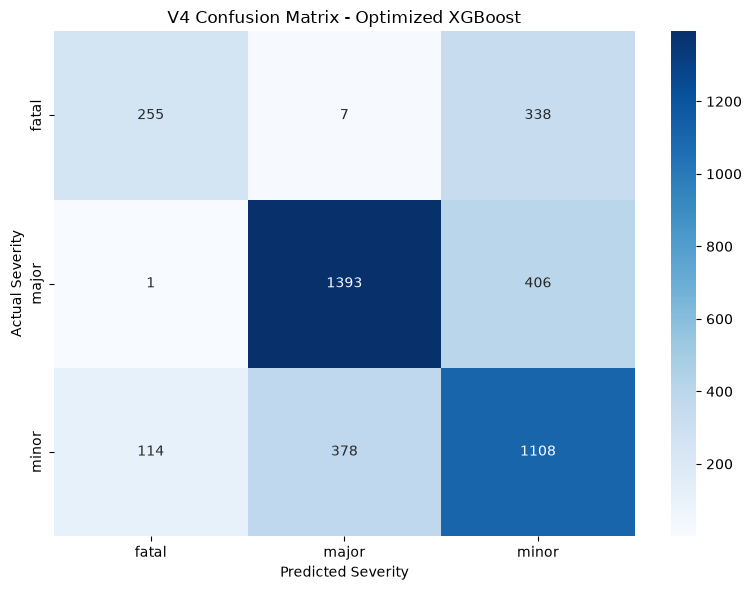


V4 - ACCURACY CROSS-CHECK
Correct predictions : 2756
Total predictions   : 4000
Accuracy            : 68.90%
Metric accuracy     : 68.90%

Both values should match.

V4 - MODEL SAVED
Model file   : model/v4_best_accident_severity_model.pkl
Encoder file : model/v4_label_encoder.pkl

V4 training completed successfully!


                  V4 EXPERIMENT SUMMARY
Dataset          : road_accident_severity_project_dataset_20000.csv
Records          : 20000
Training records : 16000
Testing records  : 4000
Features         : 31
Best model       : Optimized XGBoost
Accuracy         : 68.90%
Macro F1         : 64.88%
Weighted F1      : 68.60%
Data leakage     : NO
Test set in CV   : NO
V4 COMPLETE


In [1]:
# ============================================================
# ROAD ACCIDENT SEVERITY PREDICTION - V4
# FINAL OPTIMIZATION ATTEMPT
# NO DATA LEAKAGE
# ============================================================

%pip install -q catboost

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("==================================================")
print("V4 - LIBRARIES")
print("==================================================")
print("Libraries loaded successfully!")


# ============================================================
# 2. LOAD DATASET
# ============================================================

DATASET_PATH = (
    "dataset/road_accident_severity_project_dataset_20000.csv"
)

df = pd.read_csv(DATASET_PATH)

print("\n==================================================")
print("V4 - DATASET")
print("==================================================")

print("Dataset loaded successfully!")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])
print("Shape   :", df.shape)


# ============================================================
# 3. DATASET INSPECTION
# ============================================================

print("\n==================================================")
print("COLUMNS")
print("==================================================")

for column in df.columns:
    print("-", column)


print("\n==================================================")
print("MISSING VALUES")
print("==================================================")

print(df.isnull().sum())


print("\n==================================================")
print("TARGET DISTRIBUTION")
print("==================================================")

print(
    df["accident_severity"].value_counts()
)

print("\nPercentage:")

print(
    (
        df["accident_severity"]
        .value_counts(normalize=True) * 100
    ).round(2)
)


# ============================================================
# 4. STRICT DATA LEAKAGE PROTECTION
# ============================================================

print("\n==================================================")
print("V4 - LEAKAGE PROTECTION")
print("==================================================")

# These columns must NEVER be used as predictors.
# They are either the target itself or potentially
# derived from accident outcomes.

FORBIDDEN_COLUMNS = [
    "accident_severity",
    "casualties",
    "risk_score"
]

print("Forbidden columns:")

for column in FORBIDDEN_COLUMNS:
    print("-", column)


X = df.drop(
    columns=FORBIDDEN_COLUMNS,
    errors="ignore"
)

y = df["accident_severity"]


print("\nFeatures used for training:")

for column in X.columns:
    print("-", column)


print("\nLeakage protection: ENABLED")



# ============================================================
# 5. V4 FEATURE ENGINEERING
# ============================================================

def engineer_features(data):

    data = data.copy()

    # --------------------------------------------------------
    # TIME CYCLICAL FEATURES
    # --------------------------------------------------------

    if "hour" in data.columns:

        hour = pd.to_numeric(
            data["hour"],
            errors="coerce"
        )

        data["hour_sin"] = np.sin(
            2 * np.pi * hour / 24
        )

        data["hour_cos"] = np.cos(
            2 * np.pi * hour / 24
        )


    # --------------------------------------------------------
    # TRAFFIC DENSITY
    # --------------------------------------------------------

    if "traffic_density" in data.columns:

        traffic_map = {
            "low": 0,
            "medium": 1,
            "high": 2
        }

        data["traffic_density_score"] = (
            data["traffic_density"]
            .astype(str)
            .str.lower()
            .map(traffic_map)
        )


    # --------------------------------------------------------
    # VISIBILITY
    # --------------------------------------------------------

    if "visibility" in data.columns:

        visibility = pd.to_numeric(
            data["visibility"],
            errors="coerce"
        )

        data["visibility_squared"] = (
            visibility ** 2
        )

        data["poor_visibility"] = (
            visibility < 5
        ).astype(int)


    # --------------------------------------------------------
    # VEHICLES
    # --------------------------------------------------------

    if "vehicles_involved" in data.columns:

        vehicles = pd.to_numeric(
            data["vehicles_involved"],
            errors="coerce"
        )

        data["vehicles_squared"] = (
            vehicles ** 2
        )

        data["multi_vehicle"] = (
            vehicles >= 2
        ).astype(int)

        data["high_vehicle_count"] = (
            vehicles >= 3
        ).astype(int)


    # --------------------------------------------------------
    # LANES
    # --------------------------------------------------------

    if "lanes" in data.columns:

        lanes = pd.to_numeric(
            data["lanes"],
            errors="coerce"
        )

        data["lanes_squared"] = (
            lanes ** 2
        )

        data["multi_lane"] = (
            lanes >= 3
        ).astype(int)


    # --------------------------------------------------------
    # TEMPERATURE
    # --------------------------------------------------------

    if "temperature" in data.columns:

        temperature = pd.to_numeric(
            data["temperature"],
            errors="coerce"
        )

        data["temperature_squared"] = (
            temperature ** 2
        )

        data["extreme_temperature"] = (
            (temperature < 5) |
            (temperature > 40)
        ).astype(int)


    # --------------------------------------------------------
    # INTERACTIONS
    # --------------------------------------------------------

    if (
        "is_peak_hour" in data.columns
        and "traffic_density_score" in data.columns
    ):

        data["peak_traffic"] = (
            data["is_peak_hour"].astype(int)
            *
            data["traffic_density_score"].fillna(0)
        )


    if (
        "is_weekend" in data.columns
        and "is_peak_hour" in data.columns
    ):

        data["weekend_peak"] = (
            data["is_weekend"].astype(int)
            *
            data["is_peak_hour"].astype(int)
        )


    if (
        "vehicles_involved" in data.columns
        and "traffic_density_score" in data.columns
    ):

        vehicles = pd.to_numeric(
            data["vehicles_involved"],
            errors="coerce"
        )

        data["vehicle_traffic_interaction"] = (
            vehicles *
            data["traffic_density_score"].fillna(0)
        )


    if (
        "lanes" in data.columns
        and "traffic_density_score" in data.columns
    ):

        lanes = pd.to_numeric(
            data["lanes"],
            errors="coerce"
        )

        data["lane_traffic_interaction"] = (
            lanes *
            data["traffic_density_score"].fillna(0)
        )


    return data


X = engineer_features(X)


print("\n==================================================")
print("V4 - FEATURE ENGINEERING")
print("==================================================")

print(
    "Final feature count:",
    X.shape[1]
)

for column in X.columns:
    print("-", column)

# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)


print("\n==================================================")
print("TARGET ENCODING")
print("==================================================")

for number, label in enumerate(
    label_encoder.classes_
):
    print(
        f"{label} -> {number}"
    )


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)


print("\n==================================================")
print("TRAIN / TEST SPLIT")
print("==================================================")

print(
    "Training records:",
    len(X_train)
)

print(
    "Testing records :",
    len(X_test)
)

print("\nTest data is locked.")



# ============================================================
# 7. PREPROCESSING
# ============================================================

numeric_features = X_train.select_dtypes(
    include=[
        "int64",
        "float64",
        "int32",
        "float32"
    ]
).columns.tolist()


categorical_features = X_train.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()


numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


print("\n==================================================")
print("PREPROCESSING")
print("==================================================")

print(
    "Numerical features   :",
    len(numeric_features)
)

print(
    "Categorical features :",
    len(categorical_features)
)

print(
    "Preprocessing ready!"
)



# ============================================================
# 8. BASELINE MODELS
# ============================================================

baseline_models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )
}


baseline_results = []
baseline_models_trained = {}


print("\n==================================================")
print("V4 - BASELINE TRAINING")
print("==================================================")


for name, model in baseline_models.items():

    print(
        "\nTraining:",
        name
    )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    baseline_results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "Weighted F1": weighted_f1,

        "Macro F1": macro_f1
    })

    baseline_models_trained[name] = pipeline

    print(
        name,
        "completed!"
    )


baseline_df = pd.DataFrame(
    baseline_results
)


print("\n==================================================")
print("V4 - BASELINE RESULTS")
print("==================================================")


print(
    baseline_df.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.2%}".format,
            "Precision": "{:.2%}".format,
            "Recall": "{:.2%}".format,
            "Weighted F1": "{:.2%}".format,
            "Macro F1": "{:.2%}".format
        }
    )
)



# ============================================================
# 9. OPTIMIZED XGBOOST
# ============================================================

print("\n==================================================")
print("V4 - XGBOOST OPTIMIZATION")
print("==================================================")


xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                objective="multi:softprob",
                num_class=len(
                    label_encoder.classes_
                ),
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=1,
                tree_method="hist"
            )
        )
    ]
)


xgb_parameters = {

    "model__n_estimators": [
        300,
        500,
        700,
        900
    ],

    "model__max_depth": [
        3,
        4,
        5,
        6,
        7
    ],

    "model__learning_rate": [
        0.02,
        0.03,
        0.05,
        0.08
    ],

    "model__subsample": [
        0.75,
        0.85,
        0.95,
        1.0
    ],

    "model__colsample_bytree": [
        0.75,
        0.85,
        0.95,
        1.0
    ],

    "model__min_child_weight": [
        1,
        3,
        5,
        7
    ],

    "model__gamma": [
        0,
        0.1,
        0.3,
        0.5
    ],

    "model__reg_alpha": [
        0,
        0.01,
        0.1
    ],

    "model__reg_lambda": [
        1,
        2,
        5
    ]
}


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


xgb_search = RandomizedSearchCV(

    estimator=xgb_pipeline,

    param_distributions=xgb_parameters,

    n_iter=30,

    scoring="accuracy",

    cv=cv,

    verbose=1,

    random_state=42,

    n_jobs=-1,

    refit=True
)


print(
    "30 parameter combinations"
)

print(
    "5-fold cross-validation"
)

print(
    "Optimization metric: Accuracy"
)

print(
    "Test set remains untouched."
)


xgb_search.fit(
    X_train,
    y_train
)


print("\n==================================================")
print("XGBOOST OPTIMIZATION COMPLETED")
print("==================================================")


print(
    "Best CV Accuracy:",
    f"{xgb_search.best_score_:.2%}"
)


print("\nBest parameters:")

for parameter, value in (
    xgb_search.best_params_.items()
):

    print(
        parameter,
        ":",
        value
    )


# ============================================================
# 10. CATBOOST
# ============================================================

print("\n==================================================")
print("V4 - CATBOOST")
print("==================================================")


# CatBoost handles categorical features directly.
# We therefore create a separate copy.

X_cat = X.copy()


for column in X_cat.columns:

    if X_cat[column].dtype == "object":

        X_cat[column] = (
            X_cat[column]
            .fillna("Unknown")
            .astype(str)
        )


cat_features_indices = [
    X_cat.columns.get_loc(column)
    for column in X_cat.columns
    if X_cat[column].dtype == "object"
]


X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(
    X_cat,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)


cat_model = CatBoostClassifier(

    iterations=700,

    depth=7,

    learning_rate=0.05,

    loss_function="MultiClass",

    eval_metric="Accuracy",

    random_seed=42,

    verbose=False,

    thread_count=-1
)


print(
    "Training CatBoost..."
)


cat_model.fit(
    X_cat_train,
    y_cat_train,
    cat_features=cat_features_indices
)


cat_predictions = cat_model.predict(
    X_cat_test
).astype(int).ravel()


cat_accuracy = accuracy_score(
    y_cat_test,
    cat_predictions
)

cat_precision = precision_score(
    y_cat_test,
    cat_predictions,
    average="weighted",
    zero_division=0
)

cat_recall = recall_score(
    y_cat_test,
    cat_predictions,
    average="weighted",
    zero_division=0
)

cat_weighted_f1 = f1_score(
    y_cat_test,
    cat_predictions,
    average="weighted",
    zero_division=0
)

cat_macro_f1 = f1_score(
    y_cat_test,
    cat_predictions,
    average="macro",
    zero_division=0
)


print("\n==================================================")
print("CATBOOST PERFORMANCE")
print("==================================================")


print(
    f"Accuracy        : {cat_accuracy:.2%}"
)

print(
    f"Precision       : {cat_precision:.2%}"
)

print(
    f"Recall          : {cat_recall:.2%}"
)

print(
    f"Weighted F1     : {cat_weighted_f1:.2%}"
)

print(
    f"Macro F1        : {cat_macro_f1:.2%}"
)


# ============================================================
# 11. OPTIMIZED XGBOOST TEST RESULT
# ============================================================

optimized_xgb = xgb_search.best_estimator_

xgb_predictions = optimized_xgb.predict(
    X_test
)


xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_precision = precision_score(
    y_test,
    xgb_predictions,
    average="weighted",
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_predictions,
    average="weighted",
    zero_division=0
)

xgb_weighted_f1 = f1_score(
    y_test,
    xgb_predictions,
    average="weighted",
    zero_division=0
)

xgb_macro_f1 = f1_score(
    y_test,
    xgb_predictions,
    average="macro",
    zero_division=0
)


print("\n==================================================")
print("OPTIMIZED XGBOOST TEST PERFORMANCE")
print("==================================================")


print(
    f"Accuracy        : {xgb_accuracy:.2%}"
)

print(
    f"Precision       : {xgb_precision:.2%}"
)

print(
    f"Recall          : {xgb_recall:.2%}"
)

print(
    f"Weighted F1     : {xgb_weighted_f1:.2%}"
)

print(
    f"Macro F1        : {xgb_macro_f1:.2%}"
)


# ============================================================
# 12. V4 FINAL MODEL COMPARISON
# ============================================================

results = []


# Baseline models
for result in baseline_results:

    results.append(result)


# Optimized XGBoost
results.append({

    "Model": "Optimized XGBoost",

    "Accuracy": xgb_accuracy,

    "Precision": xgb_precision,

    "Recall": xgb_recall,

    "Weighted F1": xgb_weighted_f1,

    "Macro F1": xgb_macro_f1
})


# CatBoost
results.append({

    "Model": "CatBoost",

    "Accuracy": cat_accuracy,

    "Precision": cat_precision,

    "Recall": cat_recall,

    "Weighted F1": cat_weighted_f1,

    "Macro F1": cat_macro_f1
})


results_df = pd.DataFrame(
    results
)


# Sort primarily by Accuracy
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)


print("\n")
print("================================================================")
print("              V4 FINAL MODEL BENCHMARK")
print("================================================================")


print(
    results_df.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.2%}".format,
            "Precision": "{:.2%}".format,
            "Recall": "{:.2%}".format,
            "Weighted F1": "{:.2%}".format,
            "Macro F1": "{:.2%}".format
        }
    )
)


# ============================================================
# 13. SELECT BEST V4 MODEL
# ============================================================

best_model_name = (
    results_df.iloc[0]["Model"]
)


if best_model_name == "Optimized XGBoost":

    best_model = optimized_xgb

    y_test_final = y_test

    y_pred_final = xgb_predictions


elif best_model_name == "CatBoost":

    best_model = cat_model

    y_test_final = y_cat_test

    y_pred_final = cat_predictions


else:

    best_model = baseline_models_trained[
        best_model_name
    ]

    y_test_final = y_test

    y_pred_final = best_model.predict(
        X_test
    )


print("\n==================================================")
print("V4 - BEST MODEL")
print("==================================================")

print(
    "Best model:",
    best_model_name
)


# ============================================================
# 14. V4 FINAL RESULT
# ============================================================

final_accuracy = accuracy_score(
    y_test_final,
    y_pred_final
)

final_precision = precision_score(
    y_test_final,
    y_pred_final,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    y_test_final,
    y_pred_final,
    average="weighted",
    zero_division=0
)

final_weighted_f1 = f1_score(
    y_test_final,
    y_pred_final,
    average="weighted",
    zero_division=0
)

final_macro_f1 = f1_score(
    y_test_final,
    y_pred_final,
    average="macro",
    zero_division=0
)


print("\n")
print("================================================================")
print("                 V4 FINAL RESULT")
print("================================================================")

print(
    f"BEST MODEL       : {best_model_name}"
)

print()

print(
    f"ACCURACY         : {final_accuracy * 100:.2f}%"
)

print(
    f"PRECISION        : {final_precision * 100:.2f}%"
)

print(
    f"RECALL           : {final_recall * 100:.2f}%"
)

print(
    f"WEIGHTED F1      : {final_weighted_f1 * 100:.2f}%"
)

print(
    f"MACRO F1         : {final_macro_f1 * 100:.2f}%"
)

print("================================================================")


# ============================================================
# 14. V4 FINAL RESULT
# ============================================================

final_accuracy = accuracy_score(
    y_test_final,
    y_pred_final
)

final_precision = precision_score(
    y_test_final,
    y_pred_final,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    y_test_final,
    y_pred_final,
    average="weighted",
    zero_division=0
)

final_weighted_f1 = f1_score(
    y_test_final,
    y_pred_final,
    average="weighted",
    zero_division=0
)

final_macro_f1 = f1_score(
    y_test_final,
    y_pred_final,
    average="macro",
    zero_division=0
)


print("\n")
print("================================================================")
print("                 V4 FINAL RESULT")
print("================================================================")

print(
    f"BEST MODEL       : {best_model_name}"
)

print()

print(
    f"ACCURACY         : {final_accuracy * 100:.2f}%"
)

print(
    f"PRECISION        : {final_precision * 100:.2f}%"
)

print(
    f"RECALL           : {final_recall * 100:.2f}%"
)

print(
    f"WEIGHTED F1      : {final_weighted_f1 * 100:.2f}%"
)

print(
    f"MACRO F1         : {final_macro_f1 * 100:.2f}%"
)

print("================================================================")


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test_final,
    y_pred_final
)


plt.figure(
    figsize=(8, 6)
)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=label_encoder.classes_,

    yticklabels=label_encoder.classes_
)


plt.title(
    f"V4 Confusion Matrix - {best_model_name}"
)


plt.xlabel(
    "Predicted Severity"
)


plt.ylabel(
    "Actual Severity"
)


plt.tight_layout()

plt.show()



# ============================================================
# 17. ACCURACY CROSS-CHECK
# ============================================================

correct_predictions = np.trace(
    cm
)

total_predictions = cm.sum()


matrix_accuracy = (
    correct_predictions /
    total_predictions
)


print("\n==================================================")
print("V4 - ACCURACY CROSS-CHECK")
print("==================================================")


print(
    "Correct predictions :",
    correct_predictions
)


print(
    "Total predictions   :",
    total_predictions
)


print(
    f"Accuracy            : {matrix_accuracy * 100:.2f}%"
)


print(
    f"Metric accuracy     : {final_accuracy * 100:.2f}%"
)


print("\nBoth values should match.")


# ============================================================
# 18. SAVE V4 MODEL
# ============================================================

os.makedirs(
    "model",
    exist_ok=True
)


V4_MODEL_PATH = (
    "model/v4_best_accident_severity_model.pkl"
)


V4_ENCODER_PATH = (
    "model/v4_label_encoder.pkl"
)


joblib.dump(
    best_model,
    V4_MODEL_PATH
)


joblib.dump(
    label_encoder,
    V4_ENCODER_PATH
)


print("\n==================================================")
print("V4 - MODEL SAVED")
print("==================================================")


print(
    "Model file   :",
    V4_MODEL_PATH
)


print(
    "Encoder file :",
    V4_ENCODER_PATH
)


print("\nV4 training completed successfully!")


# ============================================================
# 19. V4 EXPERIMENT SUMMARY
# ============================================================

print("\n")
print("================================================================")
print("                  V4 EXPERIMENT SUMMARY")
print("================================================================")

print(
    "Dataset          :",
    "road_accident_severity_project_dataset_20000.csv"
)

print(
    "Records          :",
    len(df)
)

print(
    "Training records :",
    len(X_train)
)

print(
    "Testing records  :",
    len(X_test)
)

print(
    "Features         :",
    X.shape[1]
)

print(
    "Best model       :",
    best_model_name
)

print(
    "Accuracy         :",
    f"{final_accuracy * 100:.2f}%"
)

print(
    "Macro F1         :",
    f"{final_macro_f1 * 100:.2f}%"
)

print(
    "Weighted F1      :",
    f"{final_weighted_f1 * 100:.2f}%"
)

print(
    "Data leakage     : NO"
)

print(
    "Test set in CV   : NO"
)

print("================================================================")
print("V4 COMPLETE")
print("================================================================")




